In [1]:
from pathlib import Path

from dbfread import DBF
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
assert (ROOT / 'pyproject.toml').exists(), 'Не найден корень репозитория'

In [2]:
df_amd = pd.DataFrame(iter(DBF(ROOT / 'data/raw/AMD_RC_F02_09_2016_T02_09_2026.dbf', encoding='cp1251')))
df_uzs = pd.DataFrame(iter(DBF(ROOT / 'data/raw/UZS_RC_F02_09_2016_T02_09_2026.dbf', encoding='cp1251')))

In [3]:
print(df_amd.head())
print(df_amd.shape)
print(df_amd.tail())

   nominal        data     curs             cdx
0      100  2026-09-02  23.8162  Армянский драм
1      100  2026-09-01  23.7000  Армянский драм
2      100  2026-08-29  23.4960  Армянский драм
3      100  2026-08-28  23.5833  Армянский драм
4      100  2026-08-27  23.1188  Армянский драм
(2468, 4)
      nominal        data     curs             cdx
2463      100  2016-09-08  13.5681  Армянский драм
2464      100  2016-09-07  13.6629  Армянский драм
2465      100  2016-09-06  13.6346  Армянский драм
2466      100  2016-09-03  13.8670  Армянский драм
2467      100  2016-09-02  13.7382  Армянский драм


In [4]:
print(df_uzs.head())
print(df_uzs.shape)
print(df_uzs.tail())

   nominal        data     curs            cdx
0    10000  2026-09-02  73.3921  Узбекский сум
1    10000  2026-09-01  73.0760  Узбекский сум
2    10000  2026-08-29  72.5354  Узбекский сум
3    10000  2026-08-28  72.6965  Узбекский сум
4    10000  2026-08-27  71.5557  Узбекский сум
(2468, 4)
      nominal        data     curs            cdx
2463     1000  2016-09-08  21.5680  Узбекский сум
2464     1000  2016-09-07  21.6970  Узбекский сум
2465     1000  2016-09-06  21.6259  Узбекский сум
2466     1000  2016-09-03  22.0296  Узбекский сум
2467     1000  2016-09-02  21.8249  Узбекский сум


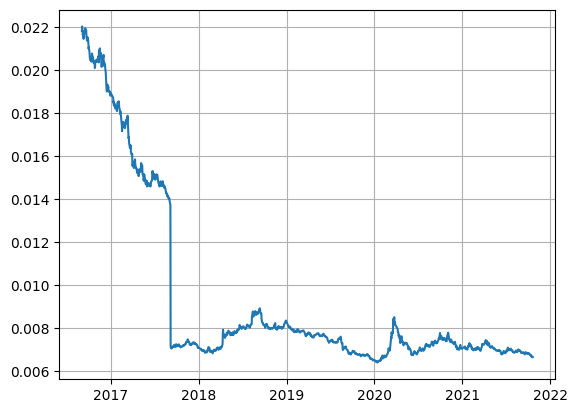

In [5]:
plt.plot(df_uzs["data"][1200:], (df_uzs["curs"]/df_uzs["nominal"])[1200:])
plt.grid(True)

# Быстрое знакомство с датасетом RUB→TJS

Ниже используются две таблицы:

- `observations` — факты, известные на дату расчёта; из них позже строятся признаки модели;
- `labels` — правильные ответы, рассчитанные с использованием будущего; они нужны только для обучения и проверки.

Таблицы соединяются по дате и направлению перевода. Будущие колонки из `labels` нельзя передавать модели как признаки.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

OBSERVATIONS_PATH = ROOT / 'data/processed/rub_tjs_observations.csv'
LABELS_PATH = ROOT / 'data/processed/rub_tjs_labels_h5_e50bp.csv'

observations = pd.read_csv(OBSERVATIONS_PATH, parse_dates=['date'])
labels = pd.read_csv(LABELS_PATH, parse_dates=['date'])
dataset = observations.merge(labels, on=['date', 'corridor'], validate='one_to_one')

print(f'Наблюдения: {len(observations):,}')
print(f'Разметка: {len(labels):,}')
print(f'После соединения: {len(dataset):,}')
display(observations.head(3))
display(labels.loc[labels['has_full_window']].head(3))

Наблюдения: 2,468
Разметка: 2,468
После соединения: 2,468


,date,corridor,currency,source,source_file,nominal,value_rub,rub_per_unit,units_per_rub,days_since_previous,same_rate_as_previous
0,2016-09-02,RUB_TJS,TJS,CBR,TJS_RC_F02_09_2016_T02_09_2026.dbf,10,83.0765,8.30765,0.120371,NaN,NaN
1,2016-09-03,RUB_TJS,TJS,CBR,TJS_RC_F02_09_2016_T02_09_2026.dbf,10,83.5363,8.35363,0.119708,1.0,False
2,2016-09-06,RUB_TJS,TJS,CBR,TJS_RC_F02_09_2016_T02_09_2026.dbf,10,82.5024,8.25024,0.121209,3.0,False


,date,corridor,horizon_calendar_days,epsilon,has_full_window,window_min_rub_per_unit,window_mean_rub_per_unit,future_min_rub_per_unit,target_good_now,message_hit,future_regret_bps,moment_advantage_bps
3,2016-09-07,RUB_TJS,5,0.005,True,8.12356,8.234293,8.12356,0.0,0.0,163.609681,-29.616718
4,2016-09-08,RUB_TJS,5,0.005,True,8.12356,8.230121,8.12356,1.0,1.0,12.798179,116.828064
5,2016-09-09,RUB_TJS,5,0.005,True,8.12356,8.216502,8.14741,1.0,1.0,0.000000,113.116044


In [7]:
complete = dataset.loc[dataset['has_full_window']].copy()

summary = pd.Series({
    'Начало периода': observations['date'].min().date(),
    'Конец периода': observations['date'].max().date(),
    'Уникальных наблюдений': observations['date'].nunique(),
    'Строк с полной разметкой': len(complete),
    'Минимальный RUB за 1 TJS': observations['rub_per_unit'].min(),
    'Максимальный RUB за 1 TJS': observations['rub_per_unit'].max(),
    'Доля target_good_now': complete['target_good_now'].mean(),
    'Доля message_hit': complete['message_hit'].mean(),
}, name='Значение')
display(summary.to_frame())

comparison = pd.crosstab(
    complete['target_good_now'].astype(int),
    complete['message_hit'].astype(int),
    rownames=['Хороший момент'],
    colnames=['Пуш правдив'],
)
display(comparison)

baseline_hit = complete['message_hit'].mean()
print(f'Случайный день правдив примерно в {baseline_hit:.1%} случаев.')
print(f'Для lift 1.3 нужно около {baseline_hit * 1.3:.1%} правдивых сигналов.')

,Значение
Начало периода,2016-09-02
Конец периода,2026-09-02
Уникальных наблюдений,2468
Строк с полной разметкой,2462
Минимальный RUB за 1 TJS,4.72982
Максимальный RUB за 1 TJS,10.6719
Доля target_good_now,0.295288
Доля message_hit,0.57108


Пуш правдив,0,1
Хороший момент,,
0,1056,679
1,0,727


Случайный день правдив примерно в 57.1% случаев.
Для lift 1.3 нужно около 74.2% правдивых сигналов.


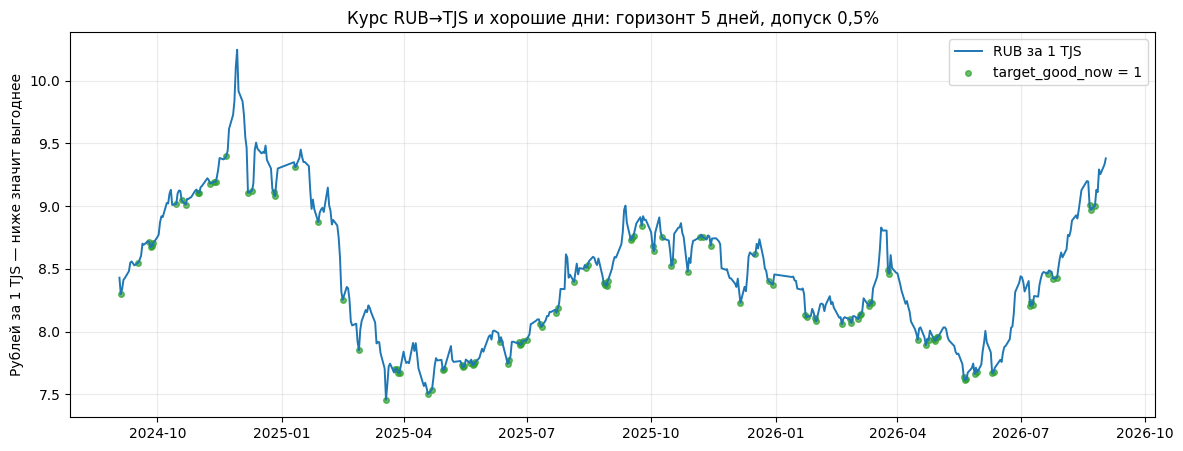

In [8]:
# Для читаемости показываем последние два года, а не весь десятилетний ряд.
chart_start = dataset['date'].max() - pd.DateOffset(years=2)
chart_data = dataset.loc[dataset['date'] >= chart_start].copy()
good_days = chart_data.loc[chart_data['target_good_now'] == 1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(chart_data['date'], chart_data['rub_per_unit'], label='RUB за 1 TJS', linewidth=1.4)
ax.scatter(
    good_days['date'],
    good_days['rub_per_unit'],
    label='target_good_now = 1',
    color='tab:green',
    s=16,
    alpha=0.7,
)
ax.set_title('Курс RUB→TJS и хорошие дни: горизонт 5 дней, допуск 0,5%')
ax.set_ylabel('Рублей за 1 TJS — ниже значит выгоднее')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Короткий вывод

- В таблице 2 468 наблюдений за десять лет; полную разметку имеют 2 462 строки.
- Около 29,5% дат считаются достаточно хорошими по правилу «±5 дней и допуск 0,5%». Это ещё не сигналы для отправки: модель должна выбрать среди них редкие и надёжные моменты.
- Примерно в 57,1% случайных дат курс в следующие пять дней не становится выгоднее более чем на 0,5%. Поэтому сигнал должен быть заметно лучше случайного дня.
- `target_good_now` строже, чем `message_hit`: он проверяет привлекательность дня и относительно прошлого, и относительно будущего.

## Как эти таблицы используются при обучении

1. Из `observations` строим признаки только по текущей дате и прошлому: изменения курса, серии, процентили и волатильность.
2. Из `labels` берём только правильный ответ `target_good_now`. Остальные будущие колонки нужны для анализа ошибок.
3. Соединяем строки по `date + corridor`. Получается таблица вида «что модель знала → какой ответ оказался правильным».
4. Делим её по времени: ранний период — обучение, следующий — подбор настроек, самый поздний — финальная проверка. Строки нельзя случайно перемешивать.

```text
прошлое                         будущее
[ обучение ] → [ настройка ] → [ финальная проверка ]
```

Так мы имитируем реальную работу: в каждый момент модель знает только прошлое, а качество проверяется на ещё не виденном будущем.

# Первая модель: логистическая регрессия

Цель первой попытки — получить понятную точку отсчёта. Мы строим признаки только из текущего и прошлых курсов, соединяем их с `target_good_now` и проверяем модель на более позднем периоде.

Абсолютный курс не передаём модели: важна текущая ситуация относительно недавней истории, а не запоминание уровня курса конкретного года.

In [9]:
import numpy as np

features = observations.sort_values('date').copy()
rate = features['rub_per_unit']

# Изменение курса: отрицательное значение означает, что перевод стал выгоднее.
for period in (1, 3, 5, 10, 20):
    features[f'return_{period}'] = rate.pct_change(periods=period, fill_method=None)

# Положение текущего курса относительно только прошлого и текущего дня.
for window in (5, 10, 20, 60):
    rolling_min = rate.rolling(window, min_periods=window).min()
    rolling_max = rate.rolling(window, min_periods=window).max()
    rolling_mean = rate.rolling(window, min_periods=window).mean()
    features[f'distance_to_min_{window}'] = rate / rolling_min - 1
    features[f'distance_to_mean_{window}'] = rate / rolling_mean - 1
    spread = (rolling_max - rolling_min).replace(0, np.nan)
    features[f'range_position_{window}'] = (rate - rolling_min) / spread

# Волатильность также считается только по предыдущим изменениям.
for window in (5, 10, 20):
    features[f'volatility_{window}'] = features['return_1'].rolling(
        window, min_periods=window
    ).std()

# Сколько реальных обновлений подряд курс снижался.
is_down = rate.diff().lt(0)
features['down_streak'] = is_down.groupby((~is_down).cumsum()).cumsum().astype(int)

# Простые календарные признаки без искусственного разрыва между декабрём и январём.
features['month_sin'] = np.sin(2 * np.pi * features['date'].dt.month / 12)
features['month_cos'] = np.cos(2 * np.pi * features['date'].dt.month / 12)
features['weekday_sin'] = np.sin(2 * np.pi * features['date'].dt.dayofweek / 7)
features['weekday_cos'] = np.cos(2 * np.pi * features['date'].dt.dayofweek / 7)

FEATURE_COLUMNS = [
    'return_1', 'return_3', 'return_5', 'return_10', 'return_20',
    'distance_to_min_5', 'distance_to_min_10', 'distance_to_min_20',
    'distance_to_min_60', 'distance_to_mean_5', 'distance_to_mean_10',
    'distance_to_mean_20', 'distance_to_mean_60', 'range_position_5',
    'range_position_10', 'range_position_20', 'range_position_60',
    'volatility_5', 'volatility_10', 'volatility_20', 'down_streak',
    'days_since_previous', 'month_sin', 'month_cos',
    'weekday_sin', 'weekday_cos',
]

outcome_columns = [
    'date', 'corridor', 'has_full_window', 'target_good_now',
    'message_hit', 'future_regret_bps', 'moment_advantage_bps',
]
model_data = features.merge(
    labels[outcome_columns], on=['date', 'corridor'], validate='one_to_one'
)
model_data = model_data.loc[model_data['has_full_window']].copy()
model_data['target_good_now'] = model_data['target_good_now'].astype(int)
model_data['message_hit'] = model_data['message_hit'].astype(int)

print(f'Строк для моделирования: {len(model_data):,}')
print(f'Признаков X: {len(FEATURE_COLUMNS)}')
display(model_data[['date', 'rub_per_unit', *FEATURE_COLUMNS[:7], 'target_good_now']].head(8))

Строк для моделирования: 2,462
Признаков X: 26


,date,rub_per_unit,return_1,return_3,return_5,return_10,return_20,distance_to_min_5,distance_to_min_10,target_good_now
3,2016-09-07,8.25868,0.001023,-0.005895,NaN,NaN,NaN,NaN,NaN,0
4,2016-09-08,8.13397,-0.015100,-0.026295,NaN,NaN,NaN,0.000000,NaN,1
5,2016-09-09,8.12356,-0.001280,-0.015355,-0.022159,NaN,NaN,0.000000,NaN,1
6,2016-09-10,8.14741,0.002936,-0.013473,-0.024686,NaN,NaN,0.002936,NaN,1
7,2016-09-13,8.26176,0.014035,0.015711,0.001396,NaN,NaN,0.017012,NaN,0
8,2016-09-14,8.20382,-0.007013,0.009880,-0.006643,NaN,NaN,0.009880,NaN,0
9,2016-09-15,8.26112,0.006985,0.013957,0.015632,NaN,NaN,0.016933,0.016933,0
10,2016-09-16,8.29205,0.003744,0.003666,0.020741,-0.001878,NaN,0.017753,0.020741,0


In [10]:
# Между периодами оставляем не менее пяти календарных дней,
# чтобы окна разметки соседних частей не пересекались.
TRAIN_END = pd.Timestamp('2022-12-26')
VALID_START = pd.Timestamp('2023-01-01')
VALID_END = pd.Timestamp('2024-12-26')
TEST_START = pd.Timestamp('2025-01-01')

train = model_data.loc[model_data['date'] <= TRAIN_END].copy()
validation = model_data.loc[
    model_data['date'].between(VALID_START, VALID_END)
].copy()
test = model_data.loc[model_data['date'] >= TEST_START].copy()

def describe_split(name, frame):
    return {
        'Период': name,
        'Начало': frame['date'].min().date(),
        'Конец': frame['date'].max().date(),
        'Строк': len(frame),
        'Доля target=1': frame['target_good_now'].mean(),
        'Доля message_hit=1': frame['message_hit'].mean(),
    }

split_summary = pd.DataFrame([
    describe_split('Обучение', train),
    describe_split('Настройка порога', validation),
    describe_split('Финальная проверка', test),
])
display(split_summary)

,Период,Начало,Конец,Строк,Доля target=1,Доля message_hit=1
0,Обучение,2016-09-07,2022-12-24,1556,0.314267,0.548201
1,Настройка порога,2023-01-10,2024-12-26,492,0.288618,0.664634
2,Финальная проверка,2025-01-10,2026-08-28,406,0.231527,0.541872


In [11]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train = train[FEATURE_COLUMNS]
y_train = train['target_good_now']

logreg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42)),
])
logreg.fit(X_train, y_train)

validation_score = logreg.predict_proba(validation[FEATURE_COLUMNS])[:, 1]
test_score = logreg.predict_proba(test[FEATURE_COLUMNS])[:, 1]

ranking_metrics = pd.DataFrame([
    {
        'Период': 'Настройка порога',
        'ROC AUC': roc_auc_score(validation['target_good_now'], validation_score),
        'Average precision': average_precision_score(
            validation['target_good_now'], validation_score
        ),
    },
    {
        'Период': 'Финальная проверка',
        'ROC AUC': roc_auc_score(test['target_good_now'], test_score),
        'Average precision': average_precision_score(test['target_good_now'], test_score),
    },
])
display(ranking_metrics)

,Период,ROC AUC,Average precision
0,Настройка порога,0.831388,0.566655
1,Финальная проверка,0.778778,0.501945


In [12]:
def make_threshold_table(frame, scores):
    thresholds = np.unique(np.quantile(scores, np.linspace(0, 1, 401)))
    weeks = max((frame['date'].max() - frame['date'].min()).days / 7, 1)
    target_baseline = frame['target_good_now'].mean()
    message_baseline = frame['message_hit'].mean()
    rows = []
    for threshold in thresholds:
        predicted = scores >= threshold
        signal_count = int(predicted.sum())
        if signal_count == 0:
            continue
        target_precision = frame.loc[predicted, 'target_good_now'].mean()
        message_precision = frame.loc[predicted, 'message_hit'].mean()
        rows.append({
            'threshold': threshold,
            'signals': signal_count,
            'signals_per_week': signal_count / weeks,
            'target_precision': target_precision,
            'target_recall': (
                frame.loc[predicted, 'target_good_now'].sum()
                / frame['target_good_now'].sum()
            ),
            'target_lift': target_precision / target_baseline,
            'message_precision': message_precision,
            'message_lift': message_precision / message_baseline,
        })
    return pd.DataFrame(rows)

validation_thresholds = make_threshold_table(validation, validation_score)
reliable = validation_thresholds.loc[
    (validation_thresholds['signals'] >= 20)
    & (validation_thresholds['target_precision'] >= 0.90)
]

if not reliable.empty:
    selected = reliable.sort_values(['signals', 'target_precision'], ascending=False).iloc[0]
    threshold_reason = 'достигнуты precision ≥ 90% и минимум 20 сигналов'
else:
    candidates = validation_thresholds.loc[validation_thresholds['signals'] >= 20]
    selected = candidates.sort_values(
        ['target_precision', 'signals'], ascending=False
    ).iloc[0]
    threshold_reason = '90% не достигнуты; выбран лучший precision при минимум 20 сигналах'

SELECTED_THRESHOLD = float(selected['threshold'])
print(f'Выбранный порог: {SELECTED_THRESHOLD:.4f}')
print(threshold_reason)

tradeoff_columns = [
    'threshold', 'signals', 'signals_per_week', 'target_precision',
    'target_recall', 'target_lift', 'message_precision', 'message_lift',
]
display(
    validation_thresholds.loc[validation_thresholds['signals'] >= 20]
    .sort_values(['target_precision', 'signals'], ascending=False)
    [tradeoff_columns]
    .head(10)
)

Выбранный порог: 0.6062
90% не достигнуты; выбран лучший precision при минимум 20 сигналах


,threshold,signals,signals_per_week,target_precision,target_recall,target_lift,message_precision,message_lift
364,0.606213,45,0.439944,0.600000,0.190141,2.078873,0.600000,0.902752
370,0.629525,37,0.361732,0.594595,0.154930,2.060145,0.594595,0.894619
369,0.627653,39,0.381285,0.589744,0.161972,2.043337,0.589744,0.887321
359,0.587598,51,0.498603,0.588235,0.211268,2.038111,0.588235,0.885051
363,0.603232,46,0.449721,0.586957,0.190141,2.033680,0.586957,0.883127
229,0.255104,210,2.053073,0.585714,0.866197,2.029376,0.619048,0.931411
367,0.618256,41,0.400838,0.585366,0.169014,2.028169,0.585366,0.880734
230,0.256311,209,2.043296,0.583732,0.859155,2.022508,0.617225,0.928669
361,0.599209,48,0.469274,0.583333,0.197183,2.021127,0.583333,0.877676
371,0.630670,36,0.351955,0.583333,0.147887,2.021127,0.583333,0.877676


In [13]:
def evaluate_at_threshold(name, frame, scores, threshold):
    predicted = scores >= threshold
    weeks = max((frame['date'].max() - frame['date'].min()).days / 7, 1)
    target_baseline = frame['target_good_now'].mean()
    message_baseline = frame['message_hit'].mean()
    target_precision = frame.loc[predicted, 'target_good_now'].mean()
    message_precision = frame.loc[predicted, 'message_hit'].mean()
    return {
        'Период и порог': name,
        'Порог': threshold,
        'Сигналов': int(predicted.sum()),
        'Сигналов в неделю': predicted.sum() / weeks,
        'Target precision': target_precision,
        'Target recall': (
            frame.loc[predicted, 'target_good_now'].sum()
            / frame['target_good_now'].sum()
        ),
        'Target baseline': target_baseline,
        'Target lift': target_precision / target_baseline,
        'Message precision': message_precision,
        'Message baseline': message_baseline,
        'Message lift': message_precision / message_baseline,
    }

evaluation = pd.DataFrame([
    evaluate_at_threshold(
        'Validation, стандартный порог 0.5', validation, validation_score, 0.5
    ),
    evaluate_at_threshold(
        'Validation, выбранный порог',
        validation, validation_score, SELECTED_THRESHOLD,
    ),
    evaluate_at_threshold(
        'Test, стандартный порог 0.5', test, test_score, 0.5
    ),
    evaluate_at_threshold(
        'Test, выбранный без просмотра test', test, test_score, SELECTED_THRESHOLD
    ),
])
display(evaluation)

,Период и порог,Порог,Сигналов,Сигналов в неделю,Target precision,Target recall,Target baseline,Target lift,Message precision,Message baseline,Message lift
0,"Validation, стандартный порог 0.5",0.500000,95,0.928771,0.515789,0.345070,0.288618,1.787102,0.526316,0.664634,0.791888
1,"Validation, выбранный порог",0.606213,45,0.439944,0.600000,0.190141,0.288618,2.078873,0.600000,0.664634,0.902752
2,"Test, стандартный порог 0.5",0.500000,106,1.247059,0.424528,0.478723,0.231527,1.833601,0.433962,0.541872,0.800858
3,"Test, выбранный без просмотра test",0.606213,37,0.435294,0.513514,0.202128,0.231527,2.217941,0.513514,0.541872,0.947666


,Признак,Коэффициент,Влияние по модулю
5,distance_to_min_5,-3.236958,3.236958
7,distance_to_min_20,0.561751,0.561751
9,distance_to_mean_5,-0.489611,0.489611
3,return_10,-0.454193,0.454193
12,distance_to_mean_60,0.439663,0.439663
2,return_5,0.369671,0.369671
18,volatility_10,-0.356358,0.356358
10,distance_to_mean_10,0.323071,0.323071
14,range_position_10,-0.295071,0.295071
13,range_position_5,-0.279943,0.279943


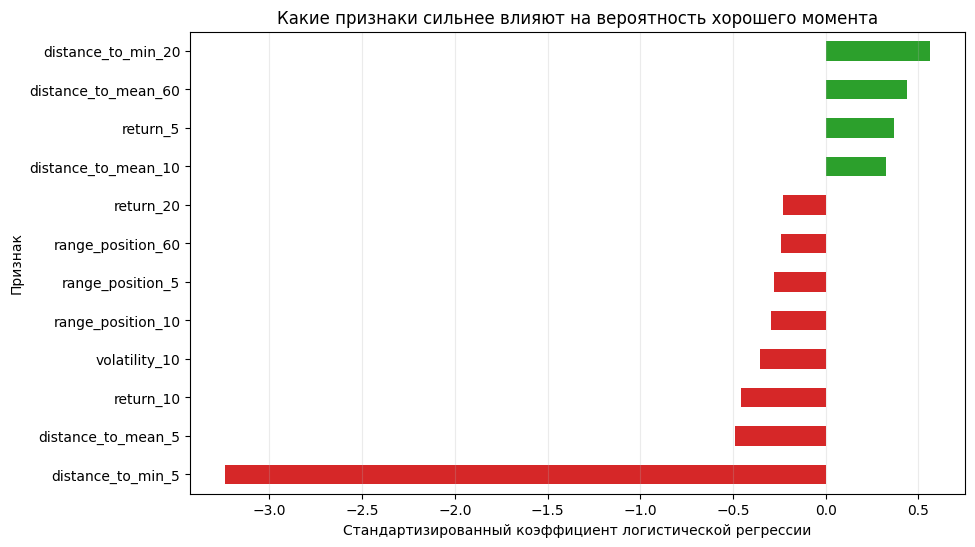

In [14]:
coefficients = pd.DataFrame({
    'Признак': FEATURE_COLUMNS,
    'Коэффициент': logreg.named_steps['model'].coef_[0],
})
coefficients['Влияние по модулю'] = coefficients['Коэффициент'].abs()
coefficients = coefficients.sort_values('Влияние по модулю', ascending=False)
display(coefficients.head(12))

top_coefficients = coefficients.head(12).sort_values('Коэффициент')
colors = np.where(top_coefficients['Коэффициент'] > 0, 'tab:green', 'tab:red')
ax = top_coefficients.plot.barh(
    x='Признак', y='Коэффициент', color=colors, legend=False, figsize=(10, 6)
)
ax.set_title('Какие признаки сильнее влияют на вероятность хорошего момента')
ax.set_xlabel('Стандартизированный коэффициент логистической регрессии')
ax.grid(axis='x', alpha=0.25)
plt.show()

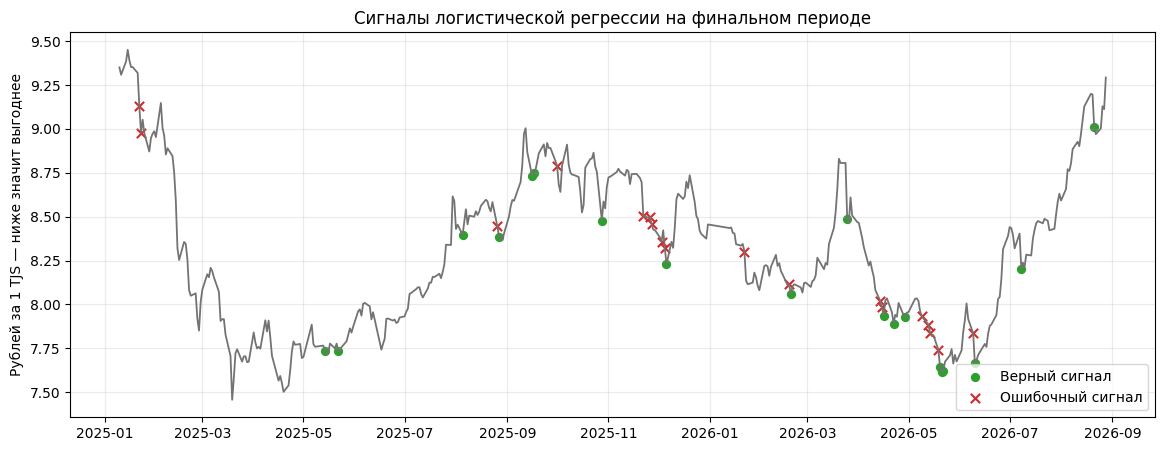

,date,rub_per_unit,target_good_now,message_hit,score,signal
2408,2026-06-10,7.66882,1,1,0.757736,True
2375,2026-04-22,7.89150,1,1,0.739987,True
2393,2026-05-20,7.64220,1,1,0.737670,True
2143,2025-05-14,7.73352,1,1,0.702058,True
2427,2026-07-08,8.20498,1,1,0.689233,True
2260,2025-10-28,8.47804,1,1,0.684196,True
2394,2026-05-21,7.61455,1,1,0.678486,True
2355,2026-03-25,8.48757,1,1,0.672439,True
2280,2025-11-26,8.49798,0,0,0.671015,True
2216,2025-08-27,8.38524,1,1,0.668324,True


In [15]:
test_view = test[['date', 'rub_per_unit', 'target_good_now', 'message_hit']].copy()
test_view['score'] = test_score
test_view['signal'] = test_view['score'] >= SELECTED_THRESHOLD
test_signals = test_view.loc[test_view['signal']]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_view['date'], test_view['rub_per_unit'], color='0.45', linewidth=1.3)
ax.scatter(
    test_signals.loc[test_signals['target_good_now'] == 1, 'date'],
    test_signals.loc[test_signals['target_good_now'] == 1, 'rub_per_unit'],
    color='tab:green', label='Верный сигнал', s=32,
)
ax.scatter(
    test_signals.loc[test_signals['target_good_now'] == 0, 'date'],
    test_signals.loc[test_signals['target_good_now'] == 0, 'rub_per_unit'],
    color='tab:red', label='Ошибочный сигнал', marker='x', s=45,
)
ax.set_title('Сигналы логистической регрессии на финальном периоде')
ax.set_ylabel('Рублей за 1 TJS — ниже значит выгоднее')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

display(test_signals.sort_values('score', ascending=False).head(15))

## Вывод по первой модели

Порог выбирается только на периоде настройки. Финальный период до этого решения не просматривается. Главные результаты нужно читать в строке **«Test, выбранный без просмотра test»**.

Результат первой попытки:

- модель ранжирует даты лучше случайного выбора: ROC AUC равен 0,831 на validation и 0,779 на test;
- требование precision 90% не достигнуто: выбранный на validation порог даёт 60,0%, а на test — 51,4%;
- target lift на test равен 2,22, но message lift равен 0,95 — правдивость пуша пока не лучше случайного дня;
- модель создаёт около 0,44 сигнала в неделю, что ниже целевого диапазона 1–2.

**Вывод:** первая логистическая регрессия полезна как baseline, но для отправки пушей не подходит. Следующий эксперимент должен улучшать именно будущую правдивость сигнала, а не только поиск локально низкого курса.